Antes de começar a codar acredito que seja importante conhecer sobre os dados que serão utilizados, desta forma fiz uma breve pesquisa saobre Abalones

O abalone é um molusco marinho gastrópode (da família Haliotidae) muito apreciado na culinária asiática, conhecido por sua carne firme e sabor suave.

Existem cerca de 50 a 60 espécies de abalone

O dataset contém a parêmetros da biometria

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sklearn as sk
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

Abrindo o arquivo CSV

In [2]:
abalone = pd.read_csv('abalone.csv')

EDA - Análise Exploratória de Dados


In [3]:
print(f"Primeiras linhas do DataFrame:\n{abalone.head()}")  # Exibindo as primeiras linhas do DataFrame
print(f"Informações sobre o DataFrame:\n{abalone.info()}")  # Exibindo informações sobre o DataFrame
print(f"Estatísticas descritivas do DataFrame:\n{abalone.describe()}")  # Exibindo estatísticas descritivas do DataFrame
print(f"Valores ausentes no DataFrame:\n{abalone.isna().sum()}")  # Verificando se há valores ausentes no DataFrame
print(f"Número de linhas do DataFrame:\n{len(abalone)}")  # Exibindo o número de linhas do DataFrame


Primeiras linhas do DataFrame:
  Sex  Length  Diameter  Height  Whole weight  Shucked weight  Viscera weight  \
0   M   0.455     0.365   0.095        0.5140          0.2245          0.1010   
1   M   0.350     0.265   0.090        0.2255          0.0995          0.0485   
2   F   0.530     0.420   0.135        0.6770          0.2565          0.1415   
3   M   0.440     0.365   0.125        0.5160          0.2155          0.1140   
4   I   0.330     0.255   0.080        0.2050          0.0895          0.0395   

   Shell weight  Rings  
0         0.150     15  
1         0.070      7  
2         0.210      9  
3         0.155     10  
4         0.055      7  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Sex             4177 non-null   object 
 1   Length          4177 non-null   float64
 2   Diameter        4177 non-null   float64
 

Visualização dos dados

Defina cores para cada categoria de sexo

In [4]:
cores_sexo = {
    'M': 'blue',
    'F': 'pink',
    'I': 'yellow'
}


Cria uma coluna com as cores

In [5]:
abalone['cor'] = abalone['Sex'].map(cores_sexo)

Gráfico de Idade (Rings) vs Comprimento (Length)

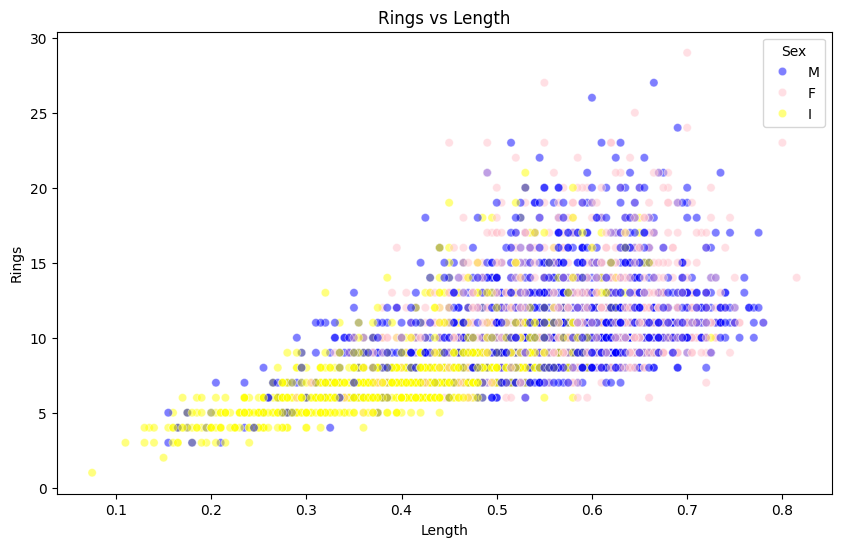

In [6]:
plt.figure(figsize=(10, 6))
sns.scatterplot( # scatterplot é um gráfico de dispersão, onde cada ponto representa uma observação do dataset, e a posição do ponto é determinada pelos valores das variáveis 'Length' e 'Rings'. O parâmetro 'hue' é usado para colorir os pontos com base na variável
    data=abalone,
    x='Length',
    y='Rings',
    hue='Sex', # O parâmetro 'hue' é usado para colorir os pontos com base
    palette={'M':'blue', 'F':'pink', 'I':'yellow'}, # O parâmetro 'palette' é usado para definir as cores específicas para cada categoria de sexo ('M', 'F', 'I') no gráfico de dispersão. Neste caso, os pontos correspondentes a 'M' serão azuis, os pontos correspondentes a 'F' serão rosa e os pontos correspondentes a 'I' serão amarelos.
    alpha=0.5
)
plt.title('Rings vs Length')
plt.show()

Gráfico de Comprimento (Length) vs Peso Total (Whole weight)

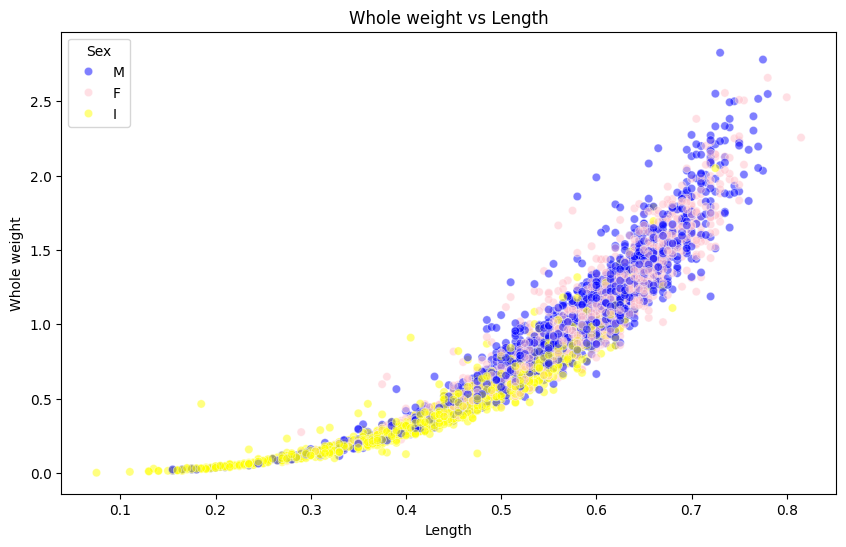

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=abalone,
    x='Length',
    y='Whole weight',
    hue='Sex',
    palette={'M':'blue', 'F':'pink', 'I':'yellow'},
    alpha=0.5
)
plt.title('Whole weight vs Length')
plt.show()


Gráfico de Altura (Height) vs Peso Sem Casca (Shucked weight)

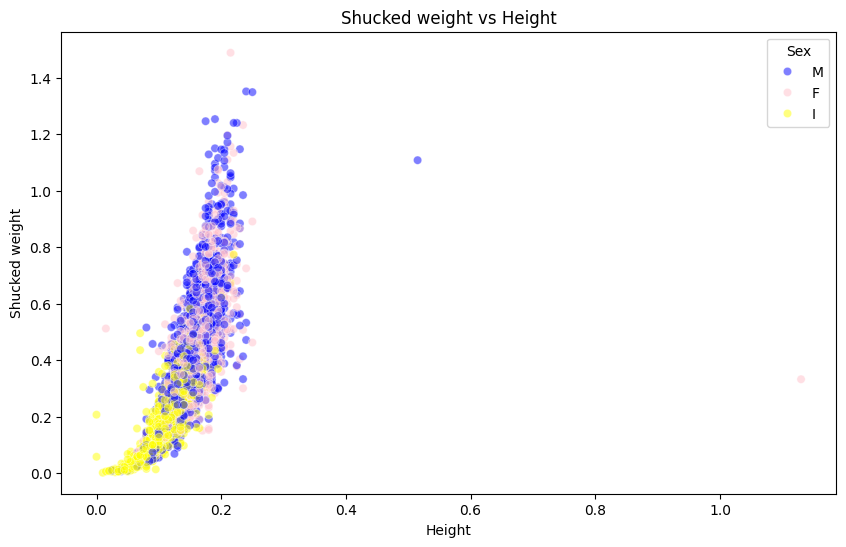

In [8]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=abalone,
    x='Height',
    y='Shucked weight',
    hue='Sex',
    palette={'M':'blue', 'F':'pink', 'I':'yellow'},
    alpha=0.5
)
plt.title('Shucked weight vs Height')
plt.show()

Histograma da distribuição dos anêis (Rings)

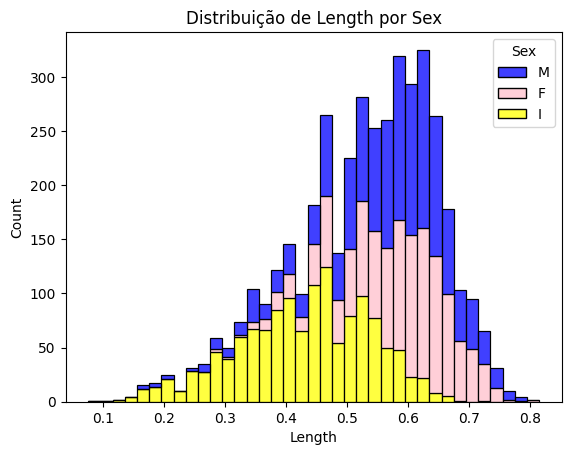

In [9]:
sns.histplot(
    data=abalone,
    x='Length',
    hue='Sex',
    palette={'M':'blue', 'F':'pink', 'I':'yellow'},
    multiple='stack'
)
plt.title('Distribuição de Length por Sex')
plt.show()

Usando modelo de regressão linear para prever a idade (Rings)

Selecionando as variáveis independentes (X) e a variável dependente (y)

In [10]:
X = abalone[['Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight', 'Viscera weight', 'Shell weight']]
y = abalone['Rings']


Configurando o K-Fold

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rsme_score é a raiz do erro quadrático médio, que é uma medida de quão bem o modelo de regressão linear está se ajustando aos dados.
Ele é calculado como a raiz quadrada da média dos erros quadráticos entre as previsões do modelo e os valores reais.
Quanto menor o RMSE, melhor o modelo está se ajustando aos dados.

r2_score é o coeficiente de determinação, que é uma medida de quão bem as previsões do modelo se ajustam aos dados.
Ele varia entre 0 e 1, onde um valor mais próximo de 1 indica um melhor ajuste do modelo aos dados.
O R² é calculado como 1 menos a razão entre a soma dos quadrados dos resíduos (diferença entre as previsões do modelo e os valores reais) e
 a soma dos quadrados totais (diferença entre os valores reais e a média dos valores reais).

Listas para armazenar as métricas

In [12]:
rmse_scores = []
r2_scores = []

In [13]:
for fold, (train_idx, test_idx) in enumerate(kf.split(X), start=1):

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]

    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    modelo = LinearRegression()
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    rmse_scores.append(rmse)
    r2_scores.append(r2)

    print(f"Fold {fold}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print("-" * 30)


Fold 1
RMSE: 2.2485
R²: 0.5330
------------------------------
Fold 2
RMSE: 2.1553
R²: 0.4822
------------------------------
Fold 3
RMSE: 2.3523
R²: 0.5244
------------------------------
Fold 4
RMSE: 2.3904
R²: 0.5198
------------------------------
Fold 5
RMSE: 2.0329
R²: 0.5167
------------------------------


In [14]:
print("\nResultado Médio dos 5 Folds")
print(f"RMSE Médio: {np.mean(rmse_scores):.4f}")
print(f"R² Médio: {np.mean(r2_scores):.4f}")


Resultado Médio dos 5 Folds
RMSE Médio: 2.2359
R² Médio: 0.5152


Análise dos Resultados

Os resultados são ok, como RMSE médio ≈ 2,24 e R² médio ≈ 0,515.

Sabendo que:
R² = 1 → modelo perfeito

R² = 0 → não é melhor que prever a média

R² < 0 → modelo ruim


Entende-se que o modelo consegue explicar cerca de 51% da variação da idade dos abalones. O que é bem frustante para um modelo. Porém, levando em consideração que são dados biológicos isso não é tão ruim. Pois existe muita variabilidade natural que não está sendo capturada apenas pelas medidas físicas.



Em relação ao RMSE, o RMSE está na mesma unidade da variável alvo (Rings), sendo RMSE ≈ 2,24 anéis. Isso significa que o modelo erra, em média, cerca de 2 anéis na estimativa da idade.


Um ponto positivo é que os folds ficaram muito parecidos: R²: 0.48 a 0.53
RMSE: 2.03 a 2.39. Isso mostra que o modelo é estável. Mas não é possível cálcular os anéis com os atríbutos presentes do dataset.

Resumo:

A regressão linear foi avaliada utilizando validação cruzada K-Fold com 5 partições. O modelo apresentou um RMSE médio de aproximadamente 2,24 anéis e um coeficiente de determinação (R²) médio de 0,51. Esses resultados indicam que o modelo consegue explicar cerca de 51% da variabilidade da idade dos abalones, apresentando desempenho moderado e comportamento consistente entre os diferentes folds da validação cruzada.


Análise do Código



O código tem como objetivo realizar uma análise exploratória e aplicar um modelo de regressão linear para prever a idade dos abalones, representada pela variável **Rings**, a partir de características biométricas do animal.

Inicialmente, foram importadas bibliotecas essenciais para manipulação de dados, visualização gráfica e modelagem estatística, incluindo Pandas, NumPy, Matplotlib, Seaborn e Scikit-Learn.

Em seguida, o conjunto de dados foi carregado a partir de um arquivo CSV utilizando a função read_csv(). Após a importação, foi realizada uma Análise Exploratória de Dados (EDA), que incluiu a visualização das primeiras linhas do conjunto de dados, a verificação dos tipos de dados, a geração de estatísticas descritivas e a identificação de possíveis valores ausentes.

Na etapa de visualização, foram construídos gráficos de dispersão para investigar possíveis relações entre as variáveis biométricas e a idade dos abalones. Os pontos foram coloridos de acordo com o sexo do animal (M, F ou I), permitindo observar diferenças visuais entre os grupos. Também foi construído um histograma para analisar a distribuição do comprimento dos abalones em cada categoria de sexo.

Para a etapa de modelagem, foram selecionadas como variáveis independentes as medidas físicas dos abalones, incluindo comprimento, diâmetro, altura e diferentes tipos de peso. A variável dependente escolhida foi o número de anéis (Rings), que é utilizado como indicador da idade do animal.

A avaliação do modelo foi realizada por meio da técnica de validação cruzada K-Fold com cinco partições. Nessa abordagem, o conjunto de dados é dividido em cinco subconjuntos. Em cada iteração, quatro subconjuntos são utilizados para treinamento e um para teste, garantindo que todos os dados sejam utilizados tanto para treinamento quanto para avaliação ao longo do processo.

Em cada fold foi treinado um modelo de Regressão Linear e calculadas as métricas RMSE (Root Mean Squared Error) e R² (Coeficiente de Determinação). O RMSE mede o erro médio das previsões na mesma unidade da variável alvo, enquanto o R² indica a proporção da variabilidade dos dados explicada pelo modelo.

Os resultados obtidos mostraram valores de R² próximos de 0,5 e RMSE em torno de 2,2 anéis, indicando que o modelo apresenta desempenho moderado. Além disso, a pequena variação das métricas entre os folds demonstra estabilidade e boa capacidade de generalização, reduzindo a probabilidade de overfitting.

De modo geral, o código segue uma estrutura adequada para um projeto de aprendizado de máquina, contemplando as etapas de carregamento dos dados, análise exploratória, visualização, treinamento do modelo e validação dos resultados.
